# Assignment 1 2AMM10 2025-2026

## Group: The Big Batch Theory
### Member 1: Haneul Choi (<insert_student_nr>)
### Member 2: Dimitar Dimitrov (<insert_student_nr>)
### Member 3: Wouter Feijen (1491032)

## Task 1 

Dataset and visualization

In [1]:
import os
import re
from pathlib import Path
from torch.utils.data import Dataset
from PIL import Image
import kagglehub
import torch
import ipywidgets as widgets
from IPython.display import display, clear_output
import matplotlib.pyplot as plt
import numpy as np
from collections import defaultdict

class AppleDataset(Dataset):
    def __init__(self, transform=None, subset="train",class_subset = "main"):
        assert subset in ["train","test"]
        assert class_subset in ["main","new","all"]
        path = kagglehub.dataset_download("moltean/fruits")
        base = Path(path) / "fruits-360_original-size" / "fruits-360-original-size"
        if subset == "train":
            self.path = base / "Training"
        elif subset == "test":
            self.path = base / "Validation"
        self.transform = transform
        all_folders = sorted(os.listdir(self.path))
        self.item_folders = sorted(x for x in all_folders if x.lower().startswith("apple"))
        generator=np.random.default_rng(6)
        generator.shuffle(self.item_folders)
        if class_subset == "main":
            self.item_folders = self.item_folders[:20]
        elif class_subset == "new":
            self.item_folders = self.item_folders[20:]
        self.targets = []
        self.image_paths = []
        for i, folder in enumerate(self.item_folders):
            for img_file in sorted(os.listdir(self.path / folder)):
                if img_file.startswith("r0"):
                    if class_subset=="new":
                        self.targets.append(i+20)
                    else: 
                        self.targets.append(i)
                    self.image_paths.append(self.path / folder / img_file)

    def __len__(self):
        return len(self.targets)

    def __getitem__(self, i):
        image = Image.open(self.image_paths[i]).convert("RGB")
        if self.transform:
            image = self.transform(image)
        return image, self.targets[i]

dataset = AppleDataset()

item_dd = widgets.Dropdown(options=dataset.item_folders, description="Variety:")
frame_slider = widgets.IntSlider(value=0, min=0, max=0, description="Frame:")
output = widgets.Output()


def get_frames(folder):
    return sorted(f for f in os.listdir(dataset.path / folder)
                  if f.startswith("r0_") and f.endswith(".jpg"))

def update_slider(*_):
    frames = get_frames(item_dd.value)
    frame_slider.max = max(0, len(frames) - 1)
    frame_slider.value = min(frame_slider.value, frame_slider.max)
    show_image()

def show_image(*_):
    frames = get_frames(item_dd.value)
    if not frames or frame_slider.value >= len(frames):
        return
    with output:
        clear_output(wait=True)
        img = Image.open(dataset.path / item_dd.value / frames[frame_slider.value])
        fig, ax = plt.subplots(figsize=(4, 4))
        ax.imshow(img)
        ax.set_title(f"{item_dd.value} | frame {frame_slider.value}")
        ax.axis("off")
        plt.tight_layout()
        plt.show()

item_dd.observe(update_slider, names="value")
frame_slider.observe(show_image, names="value")

update_slider()
display(widgets.VBox([item_dd, frame_slider, output]))

100%|██████████| 5.99G/5.99G [08:20<00:00, 12.8MB/s]

Extracting files...


In [2]:
# additional imports
from torchvision import transforms
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data.sampler import BatchSampler
from itertools import combinations
from tqdm.auto import tqdm
from sklearn.manifold import TSNE

# use cuda if available
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

Using device: cuda


In [3]:
transform = transforms.Compose([
    transforms.Resize((128, 128)),
    transforms.ToTensor(),
    transforms.Normalize(mean=(0.6123, 0.5190, 0.4066), std=(0.2739, 0.3120, 0.3521))
])# ... # your code here

train_data = AppleDataset(subset="train",transform=transform)
test_data = AppleDataset(subset="test",transform=transform)
support_new_data = AppleDataset(subset="train",transform=transform,class_subset="new")
test_new_data = AppleDataset(subset="test",transform=transform,class_subset="new")

# your code here
# Number of samples in each dataset
print(f"Number of samples in train_data: {len(train_data)}")
print(f"Number of samples in test_data: {len(test_data)}")
print(f"Number of samples in support_new_data: {len(support_new_data)}")
print(f"Number of samples in test_new_data: {len(test_new_data)}")

# Classes in each dataset
print()
print(f"Classes in train_data: {set(train_data.targets)}")
print(f"Classes in test_data: {set(test_data.targets)}")
print(f"Classes in support_new_data: {set(support_new_data.targets)}")
print(f"Classes in test_new_data: {set(test_new_data.targets)}")


Number of samples in train_data: 3068
Number of samples in test_data: 1538
Number of samples in support_new_data: 1570
Number of samples in test_new_data: 781

Classes in train_data: {0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19}
Classes in test_data: {0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19}
Classes in support_new_data: {20, 21, 22, 23, 24, 25, 26, 27, 28, 29}
Classes in test_new_data: {20, 21, 22, 23, 24, 25, 26, 27, 28, 29}


#### Step 1) EmbeddingNet

In [4]:
# Step 1) EmbeddingNet
class Lambda(nn.Module):
    def __init__(self, func):
        super().__init__()
        self.func = func

    def forward(self, x):
        return self.func(x)


# - Hierarchical Feature Extraction; first conv2d layers learn edges / colors while deeper layers may learn complex textures, shapes
# - Batch Norm: normalizes the inputs of each layer, stabilising the learning process
# - Dim reduction (AdaptiveAvgPool2d): averrage feature maps down to a single 1x1x256 vector preventing the fully connected layers
#       from containing an excessively large number of parameters, mitigating the risk of overfitting
# - L2 norm: normalize so that the Euclidean distance and cosine similarity become directly proportional, which bounds the embedding
#       space making it much easier for the loss func to push and pull embeddings predictably
class EmbeddingNet(nn.Module):
    
    def __init__(self, embedding_dim=128):
        super(EmbeddingNet, self).__init__()

        # Feature Extractor
        self.front_layer = nn.Sequential(
            # Conv Layer 1
            nn.Conv2d(in_channels=3, out_channels=32, kernel_size=3, padding=1),
            nn.BatchNorm2d(32), 
            nn.ReLU(inplace=True),
            nn.Conv2d(in_channels=32, out_channels=64, kernel_size=3, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(kernel_size=2, stride=2),

            # Conv Layer 2
            nn.Conv2d(in_channels=64, out_channels=128, kernel_size=3, padding=1),
            nn.BatchNorm2d(128),
            nn.ReLU(inplace=True),
            nn.Conv2d(in_channels=128, out_channels=128, kernel_size=3, padding=1),
            nn.BatchNorm2d(128),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(kernel_size=2, stride=2),

            # Conv Layer 3
            nn.Conv2d(in_channels=128, out_channels=256, kernel_size=3, padding=1),
            nn.BatchNorm2d(256),
            nn.ReLU(inplace=True),
            nn.Conv2d(in_channels=256, out_channels=256, kernel_size=3, padding=1),
            nn.BatchNorm2d(256),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(kernel_size=2, stride=2),

            # Adaptive Average Pooling (flatten spatial dimensions)
            nn.AdaptiveAvgPool2d((1, 1)),

            Lambda(lambda x: x.view(x.size(0), -1)),

            # Fully Connected Layer
            nn.Linear(256, 512),
            nn.ReLU(inplace=True),
            nn.Linear(512, 1024),
            nn.ReLU(inplace=True)
        )

        # final linear projection down to the target embedding_dim
        self.last_layer = nn.Linear(1024, embedding_dim)

    def forward(self, x):
        x = self.front_layer(x)
        x = self.last_layer(x)

        # processes the output to have a euclidean norm of 1
        x = F.normalize(x, p=2, dim=1)
        return x

    def get_embedding(self, x):
        return self.forward(x)

#### Step 2) BalancedBatchSampler

In [5]:
# Step 2) BalancedBatchSampler
# - To make TripletLoss with an Informative Mining strategy work effectively, we must have valid triplets (a,p,n) in
#   every single batch; we cannot randomly sample images from the dataset 
#   -> BalancedBatchSampler guarantees every batch contains a
#       - set number of specific classes
#       - set number of instances per class 
#      so that InformativeTripleSelector has a valid pool of images to mine effective triplets from during every
#      forward pass

class BalancedBatchSampler(BatchSampler):
    """Guarantees the composition of every single batch consists of a specific number of classes (n_classes)
    and a specific number of instances per class (n_samples), and that it contains valid positive pairs together
    with a variety of negative options."""
    
    def __init__(self, labels, n_classes, n_samples):
        self.labels = labels
        self.labels_set = list(set(self.labels))
        self.label_to_indices = {label: np.where(np.array(self.labels) == label)[0]
                                 for label in self.labels_set}
        for label in self.labels_set:
            np.random.shuffle(self.label_to_indices[label])
        self.used_label_indices_count = {label: 0 for label in self.labels_set}
        self.count = 0

        self.n_classes = n_classes
        self.n_samples = n_samples
        self.n_dataset = len(self.labels)
        self.batch_size = self.n_classes * self.n_samples

    def __iter__(self):
        self.count = 0
        while self.count + self.batch_size < self.n_dataset:
            classes = np.random.choice(self.labels_set, self.n_classes, replace=False)
            indices = []
            for class_ in classes:
                indices.extend(self.label_to_indices[class_]
                               [self.used_label_indices_count[class_]:self.used_label_indices_count[class_]
                                 + self.n_samples])
                self.used_label_indices_count[class_] += self.n_samples
                if self.used_label_indices_count[class_] + self.n_samples > len(self.label_to_indices[class_]):
                    np.random.shuffle(self.label_to_indices[class_])
                    self.used_label_indices_count[class_] = 0
            yield indices
            self.count += self.batch_size

    def __len__(self):
        return self.n_dataset // self.batch_size

#### Step 3) TripletLoss

In [6]:
# Step 3) TripletLoss
# -> Goal: learning similar embeddings for images of the same item, and different embeddings
#       for images of different items (TripletLoss combined with an Informative Triplet Mining strategy is
#       the industry standard for such problems).
#       - TripletLoss: TripletLoss looks at three images at once rather than looking at one image and trying to guess
#           1. Anchor: baseline image
#           2. Positive: another image of same item as anchor
#           3. negative: image of different item
#           -> Loss mathematically forces the distance between the Anchor and the Positive to be smaller than the 
#              distance between the Anchor and the Negative (plus predefined margin of 1)
#               L = max(0, ||f(a)-f(p)||^2 - ||f(a)-f(n)||^2 + margin)
#                   -> distance tussen a en p wordt kleiner, terwijl die tussen a en n kleiner wordt
#       - InformativeTripleSelector: looks for (semi-)hard negatives where the model is currently failing, forcing the
#           model to learn subtle/fine-grained differences between the apples

# Informative Triplet Selector
def pdist(vectors):
    distance_matrix = -2 * vectors.mm(torch.t(vectors)) + vectors.pow(2).sum(dim=1).view(1, -1) + vectors.pow(2).sum(
        dim=1).view(-1, 1)
    return distance_matrix

# -> actual 'negative mining'; BalancedBatchSampler feeds a carefully constructed batch into the network, and the model
#    outputs 200 embeddings which are then passed into the InformativeTripletSelector:
#    - Pairing: find every possible positive pair in the batch (anchor,positive)
#    - Distance Computation: compute distance between anchor and positive (ap_distances)
#    - Mining: compare ap_distances against all other apples in the batch (negatives) by computing math. difference:
#      ap_distance - an_distance + margin (part ot loss function!)
#    - Selection: search for negatives where the calculation above is greater than 0; then the network thinks it looks
#      too similar to the Anchor comprising the hard and semi-hard negatives
#       -> these form the final triplets used to compute the loss
class InformativeTripletSelector():
    def __init__(self, margin):
        super(InformativeTripletSelector, self).__init__()
        self.margin = margin

    def informative_negative(self, loss_values):

        informative_negative = np.where(loss_values > 0)[0]
        return np.random.choice(informative_negative) if len(informative_negative) > 0 else None
    
    def get_triplets(self, embeddings, labels):

        if torch.cuda.is_available():
            embeddings = embeddings.detach().cpu()
            labels = labels.detach().cpu().numpy()

        distance_matrix = pdist(embeddings)
        distance_matrix = distance_matrix.cpu()

        triplets = []

        for label in set(labels):
            label_mask = (labels == label)
            label_indices = np.where(label_mask)[0]
            if len(label_indices) < 2:
                continue
            negative_indices = np.where(~label_mask)[0]
            anchor_positives = list(combinations(label_indices, 2))
            anchor_positives = np.array(anchor_positives)

            ap_distances = distance_matrix[anchor_positives[:, 0], anchor_positives[:, 1]]
            for anchor_positive, ap_distance in zip(anchor_positives, ap_distances):
                loss_values = ap_distance - distance_matrix[anchor_positive[0], negative_indices] + self.margin
                loss_values = loss_values.data.cpu().numpy()

                informative_negative = self.informative_negative(loss_values)
                if informative_negative is not None:
                    informative_negative = negative_indices[informative_negative]
                    triplets.append([anchor_positive[0], anchor_positive[1], informative_negative])
        
        if len(triplets) == 0:
            triplets.append([anchor_positive[0], anchor_positive[1], negative_indices[0]])

        return torch.LongTensor(np.array(triplets))
    
# Validation Triplet Selector (Random Triplet Selector)
class RandomTripletSelector():
    def __init__(self):
        super(RandomTripletSelector, self).__init__()

    def get_triplets(self, embeddings, labels):
        labels = labels.detach().cpu().numpy()
        triplets = []

        for label in set(labels):
            label_mask = (labels == label)
            label_indices = np.where(label_mask)[0]
            if len(label_indices) < 2:
                continue
            negative_indices = np.where(~label_mask)[0]
            anchor_positives = list(combinations(label_indices, 2))

            temp_triplets = [[anchor_positive[0], anchor_positive[1], np.random.choice(negative_indices)] for anchor_positive in anchor_positives]
            triplets += temp_triplets

        return torch.LongTensor(np.array(triplets))
    
# Triplet loss function
class TripletLoss(nn.Module):
    def __init__(self, margin, triplet_selector):
        super(TripletLoss, self).__init__()
        self.margin = margin
        self.triplet_selector = triplet_selector

    def forward(self, embeddings, labels):

        triplets = self.triplet_selector.get_triplets(embeddings, labels)

        if embeddings.is_cuda:
            triplets = triplets.cuda()

        anchor_idx = triplets[:, 0]
        positive_idx = triplets[:, 1]
        negative_idx = triplets[:, 2]

        ap_distances = (embeddings[anchor_idx] - embeddings[positive_idx]).pow(2).sum(1)  # .pow(.5)
        an_distances = (embeddings[anchor_idx] - embeddings[negative_idx]).pow(2).sum(1)  # .pow(.5)
        losses = F.relu(ap_distances - an_distances + self.margin)

        return losses.mean()

#### Step 4) Training loop

In [7]:
def plot_loss_history(train_losses, validation_losses):
    n_epochs = len(train_losses)
    plt.figure(figsize=(10, 5))
    plt.plot(range(1, n_epochs + 1), train_losses, label='Train Loss')
    plt.plot(range(1, n_epochs + 1), validation_losses, label='Validation Loss')
    plt.xlabel('Epoch')
    plt.ylabel('Loss')
    plt.title('Train and Validation Loss per Epoch')
    plt.legend()
    plt.show()

# Step 4) Training loop
class Trainer():
    def __init__(self,
                 model: nn.Module,
                 device: torch.device,
                 criterion: nn.Module,
                 optimizer: torch.optim.Optimizer,
                 train_DataLoader: torch.utils.data.DataLoader,
                 validation_DataLoader: torch.utils.data.DataLoader,
                 n_epochs: int,
                 criterion_validation: nn.Module = None
                 ):
        
        self.model = model
        self.device = device
        self.criterion = criterion
        self.optimizer = optimizer
        self.train_DataLoader = train_DataLoader
        self.validation_DataLoader = validation_DataLoader
        self.n_epochs = n_epochs

        if criterion_validation is None:
            self.criterion_validation = criterion
        else:
            self.criterion_validation = criterion_validation

    def run_trainer(self):

        train_losses_per_epoch = []
        validation_losses_per_epoch = []

        for epoch in range(self.n_epochs):

            self.model.train()

            train_losses = []

            train_bar = tqdm(
            enumerate(self.train_DataLoader),
            total=len(self.train_DataLoader),
            desc=f"Training epoch {epoch + 1}/{self.n_epochs}",
            leave=True,
            dynamic_ncols=True
            )
            
            for batch_idx, batch in train_bar:

                x, y = batch
                input, target = x.to(self.device), y.to(self.device)
                self.optimizer.zero_grad()
                output = self.model(input)
                loss = self.criterion(output, target)

                loss_value = loss.item()
                train_losses.append(loss_value)

                train_bar.set_postfix({
                "batch": f"{batch_idx + 1}/{len(self.train_DataLoader)}",
                "loss": f"{loss_value:.4f}",
                "avg_loss": f"{np.mean(train_losses):.4f}"
                })

                loss.backward()
                self.optimizer.step()

            self.model.eval()
            validation_losses = []

            validation_bar = tqdm(
                enumerate(self.validation_DataLoader),
                total=len(self.validation_DataLoader),
                desc=f"Validation epoch {epoch + 1}/{self.n_epochs}",
                leave=True,
                dynamic_ncols=True
            )

            for batch_idx, batch in validation_bar:

                x, y = batch
                input, target = x.to(self.device), y.to(self.device)
                
                with torch.no_grad():
                    output = self.model(input)
                    loss = self.criterion_validation(output, target)

                    loss_value = loss.item()
                    validation_losses.append(loss_value)

                    validation_bar.set_postfix({
                    "batch": f"{batch_idx + 1}/{len(self.validation_DataLoader)}",
                    "loss": f"{loss_value:.4f}",
                    "avg_loss": f"{np.mean(validation_losses):.4f}"
                    })
            
            train_losses_per_epoch.append(np.mean(train_losses))
            validation_losses_per_epoch.append(np.mean(validation_losses))

            # Print epoch, train loss and validation loss
            print(f"Epoch: {epoch + 1}/{self.n_epochs}, Train Loss: {np.mean(train_losses):.4f}, Validation Loss: {np.mean(validation_losses):.4f}")

        # plot train and validation losses per epoch
        plot_loss_history(train_losses_per_epoch, validation_losses_per_epoch)
        # plt.figure(figsize=(10, 5))
        # plt.plot(range(1, self.n_epochs + 1), train_losses_per_epoch, label='Train Loss')
        # plt.plot(range(1, self.n_epochs + 1), validation_losses_per_epoch, label='Validation Loss')
        # plt.xlabel('Epoch')
        # plt.ylabel('Loss')
        # plt.title('Train and Validation Loss per Epoch')
        # plt.legend()
        # plt.show()

        return train_losses_per_epoch,validation_losses_per_epoch

#### Step 5: Training the model

Using device: cuda
Found existing model weights. Loading...
Model loaded successfully!


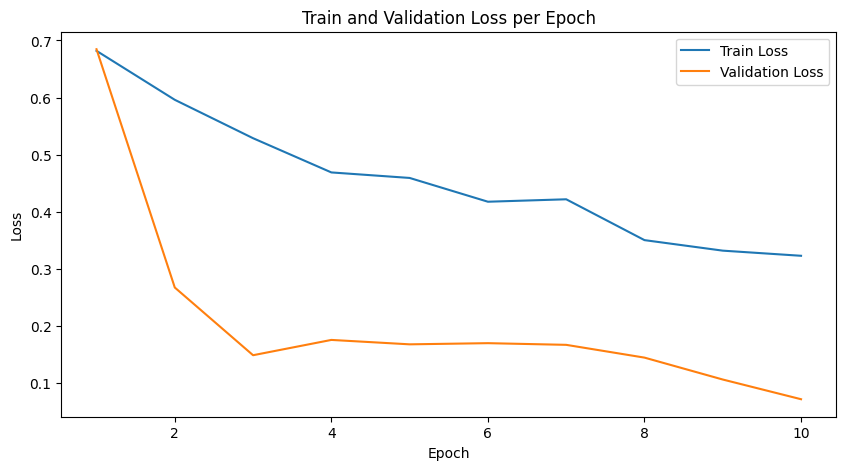

In [13]:
# Step 5: Training the model

# device
if torch.cuda.is_available():
    device = torch.device("cuda")
else:
    device = torch.device("cpu")

print(f"Using device: {device}")

# init model and save path
embedding_net = EmbeddingNet(embedding_dim=128).to(device)
# base_path = r"/home/wouterf/Documents/DS&AI Courses/DL/assignment-1"
base_path = r"C:\Users\wfeij\Documents\Local Course Files\Deep Learning\DL Assignment 1"
model_save_path = os.path.join(base_path,"embedding_net_weights.pth")

# margin
margin = 1

# criterion
triplet_selector = InformativeTripletSelector(margin=margin)
criterion = TripletLoss(margin=margin, triplet_selector=triplet_selector)

validation_selector = RandomTripletSelector()
criterion_validation = TripletLoss(margin=margin, triplet_selector=validation_selector)

# optimizer
optimizer = torch.optim.Adam(embedding_net.parameters(), lr=1e-3, weight_decay=1e-5)

# batch sampler and dataloader
train_batch_sampler = BalancedBatchSampler(train_data.targets, n_classes=10, n_samples=20)
validation_batch_sampler = BalancedBatchSampler(test_data.targets, n_classes=10, n_samples=20)
train_loader = torch.utils.data.DataLoader(train_data, batch_sampler=train_batch_sampler)
validation_loader = torch.utils.data.DataLoader(test_data, batch_sampler=validation_batch_sampler)

if os.path.exists(model_save_path):
    print("Found existing model weights. Loading...")
    # load dictionary
    checkpoint = torch.load(model_save_path, map_location=device, weights_only=False)

    # load weights and set model to eval mode
    embedding_net.load_state_dict(checkpoint["model_state_dict"])
    embedding_net.eval()
    print("Model loaded successfully!")

    plot_loss_history(checkpoint['train_losses'], checkpoint['validation_losses'])
else:
    print("No saved weights found. Starting training...")

    # training
    train = Trainer(model=embedding_net,
                    device=device,
                    criterion=criterion,
                    optimizer=optimizer,
                    train_DataLoader=train_loader,
                    validation_DataLoader=validation_loader,
                    n_epochs=10,
                    criterion_validation=criterion_validation)

    train_losses,val_losses = train.run_trainer()

    # create checkpoint
    checkpoint = {
        'model_state_dict': embedding_net.state_dict(),
        'train_losses': train_losses,
        'validation_losses': val_losses
    }

    # save model weights
    torch.save(checkpoint,model_save_path)
    print(f"Training Complete. Model saved to {model_save_path}")

#### Sanity Check: t-SNE plot
Identical apples should be grouped together while different ones should be apart.

In [ ]:
def plot_tsne_embeddings(embeddings, labels, xlim=None, ylim=None):
    tsne = TSNE(n_components=2)
    embeddings_2d = tsne.fit_transform(embeddings)

    plt.figure(figsize=(10, 10))
    scatter = plt.scatter(embeddings_2d[:, 0], embeddings_2d[:, 1], c=labels, cmap='tab10', alpha=0.7)
    plt.legend(*scatter.legend_elements(), title="Classes")
    plt.title("t-SNE Visualization of Embeddings")
    if xlim:
        plt.xlim(xlim)
    if ylim:
        plt.ylim(ylim)
    plt.show()

# get embeddings of train data and visualize
embedding_net.eval()
train_embeddings = []
train_labels = []
with torch.no_grad():
    for x, y in train_loader:
        x = x.to(device)
        embeddings = embedding_net.get_embedding(x)
        train_embeddings.append(embeddings.cpu())
        train_labels.append(y)
train_embeddings = torch.cat(train_embeddings).numpy()
train_labels = torch.cat(train_labels).numpy()

plot_tsne_embeddings(train_embeddings, train_labels)

#### 1.4, 1.5) Classification of seen apples at (un)seen angles

In [ ]:
from scipy.spatial.distance import cdist
import numpy as np
import torch
from torch.utils.data import DataLoader
from tqdm.auto import tqdm

In [ ]:
def extract_embeddings(dataset, model, batch_size=128):
    loader = torch.utils.data.DataLoader(
        dataset,
        batch_size=batch_size,
        shuffle=False,
        num_workers=0,
        pin_memory=torch.cuda.is_available()
    )

    embeddings_list = []
    labels_list = []

    model.eval()

    with torch.no_grad():
        for images, labels in tqdm(loader, desc="Extracting embeddings"):
            images = images.to(device, non_blocking=True)

            embeddings = model.get_embedding(images)

            embeddings_list.append(embeddings.cpu().numpy())
            labels_list.append(labels.numpy())

    embeddings = np.concatenate(embeddings_list, axis=0)
    labels = np.concatenate(labels_list, axis=0)

    return embeddings, labels

# k-nearest neighbors
def retrieval_classification_accuracy(reference_embeddings, reference_labels,
                                      query_embeddings, query_labels,
                                      k=1):
    # compute Euclidean distances betweeen every query embedding and every reference embedding
    distances = cdist(query_embeddings, reference_embeddings)

    predictions = []

    # for each query, sort the distances to fnd the k=5 closest training embeddings
    for query_idx in range(len(query_embeddings)):
        sorted_idx = np.argsort(distances[query_idx])
        top_k_idx = sorted_idx[:k]
        top_k_labels = reference_labels[top_k_idx]

        # look at k=5 closest training images and assign the most frequent label to the query image
        values, counts = np.unique(top_k_labels, return_counts=True)
        predicted_label = values[np.argmax(counts)]

        predictions.append(predicted_label)

    predictions = np.array(predictions)
    accuracy = np.mean(predictions == query_labels)

    return accuracy, predictions

# ======= 1.4) Evaluation on seen apples =======
# Extract embeddings from train and test datasets
#   -> model converts every image into a 128dim embedding

# get reference embeddings and labels; model was trained on these images, so known where they
# exist in the 128dim space & what their labels are
train_embeddings, train_labels = extract_embeddings(train_data, embedding_net)
# get query embeddings and labels -> model maps to the 128dim space, and we can use retrievel_classification_accuracy
# to classify these according to k-NN (query labels used are kept hidden until accuracy computation)
test_embeddings, test_labels = extract_embeddings(test_data, embedding_net)

# Evaluate retrieval-based classification accuracy (seen data)
accuracy, predictions = retrieval_classification_accuracy(train_embeddings, train_labels, test_embeddings, test_labels, k=5)
print(f"Retrieval-based classification accuracy on seen data (k=5): {accuracy:.4f}")

# ======= 1.5) Evaluation on unseen apples =======
# Extract embeddings from support_new_data and test_new_data
# get support embeddings of the 10 unseen types of apples
support_new_embeddings, support_new_labels = extract_embeddings(support_new_data, embedding_net)
test_new_embeddings, test_new_labels = extract_embeddings(test_new_data, embedding_net)
# -> few-shot generalization; new apple varieties can still naturally form new clusters in empty areas of the 
#    embedding space

# Evaluate retrieval-based classification accuracy (unseen data)
accuracy_new, predictions_new = retrieval_classification_accuracy(support_new_embeddings, support_new_labels,test_new_embeddings, test_new_labels, k=5)

print(f"Retrieval-based classification accuracy on unseen data (k=5): {accuracy_new:.4f}")

## Task 2

In [ ]:
class GardenDataset(Dataset):
    def __init__(self, transform=None, class_level="item", subset="train", family_subset="main", item_subset="main"):
        assert class_level in ["item","family","both"]
        assert subset in ["train","test"]
        assert family_subset in ["main","new","all"]
        assert item_subset in ["main","new","all"]
        path = kagglehub.dataset_download("moltean/fruits")
        base = Path(path) / "fruits-360_original-size" / "fruits-360-original-size"
        if subset == "train":
            self.path = base / "Training"
        elif subset == "test":
            self.path = base / "Validation"
        self.transform = transform
        self.class_level = class_level

        canonical_items = sorted(
            d for d in os.listdir(base / "Training")
            if (base / "Training" / d).is_dir() and re.fullmatch(r'\S+ \d+', d)
        )
        item_to_family = {it: it.rsplit(' ', 1)[0] for it in canonical_items}
        canonical_families = sorted(set(item_to_family.values()))

        self.item_to_idx = {c: i for i, c in enumerate(canonical_items)}
        self.family_to_idx = {c: i for i, c in enumerate(canonical_families)}

        train_fam_to_items = defaultdict(list)
        for it in canonical_items:
            train_fam_to_items[item_to_family[it]].append(it)
        for fam in train_fam_to_items:
            train_fam_to_items[fam].sort(key=lambda x: int(x.rsplit(' ', 1)[1]))

        new_families = {fam for fam, its in train_fam_to_items.items() if len(its) == 1}
        new_items = set()
        for fam, its in train_fam_to_items.items():
            if len(its) >= 3:
                new_items.add(its[0]) 

        present = {
            d for d in os.listdir(self.path)
            if (self.path / d).is_dir() and re.fullmatch(r'\S+ \d+', d)
        }
        all_items = [it for it in canonical_items if it in present]

        if family_subset == "main":
            all_items = [it for it in all_items if item_to_family[it] not in new_families]
        elif family_subset == "new":
            all_items = [it for it in all_items if item_to_family[it] in new_families]

        if item_subset == "main":
            all_items = [it for it in all_items if it not in new_items]
        elif item_subset == "new":
            all_items = [it for it in all_items if it in new_items]

        self.items = all_items
        self.item_to_family = {it: item_to_family[it] for it in self.items}
        self.families = sorted(set(self.item_to_family.values()))
        self.new_families = new_families
        self.new_items = new_items

        # Build samples using canonical (global) indices
        self.image_paths = []
        self.targets_item = []
        self.targets_family = []
        for item in self.items:
            item_dir = self.path / item
            item_label = self.item_to_idx[item]
            family_label = self.family_to_idx[item_to_family[item]]
            for img_file in sorted(os.listdir(item_dir)):
                if img_file.endswith('.jpg'):
                    self.image_paths.append(item_dir / img_file)
                    self.targets_item.append(item_label)
                    self.targets_family.append(family_label)

        if class_level == "item":
            self.classes = self.items
            self.class_to_idx = self.item_to_idx
            self.targets = self.targets_item
        elif class_level == "family":
            self.classes = self.families
            self.class_to_idx = self.family_to_idx
            self.targets = self.targets_family

    def __len__(self):
        return len(self.image_paths)

    def __getitem__(self, idx):
        image = Image.open(self.image_paths[idx]).convert("RGB")
        if self.transform:
            image = self.transform(image)
        if self.class_level == "both":
             return image, self.targets_family[idx], self.targets_item[idx]
        return image, self.targets[idx]

    def get_items_for_family(self, family):
        return sorted(item for item, fam in self.item_to_family.items() if fam == family)

dataset = GardenDataset()

family_dd = widgets.Dropdown(options=dataset.families, description="Family:")
item_dd = widgets.Dropdown(options=dataset.get_items_for_family(dataset.families[0]), description="Item:")
frame_slider = widgets.IntSlider(value=0, min=0, max=0, description="Frame:")
output = widgets.Output()


def get_frames(item):
    return sorted(f for f in os.listdir(dataset.path / item) if f.endswith(".jpg"))

def update_items(*_):
    items = dataset.get_items_for_family(family_dd.value)
    item_dd.options = items
    item_dd.value = items[0]

def update_slider(*_):
    frames = get_frames(item_dd.value)
    frame_slider.max = max(0, len(frames) - 1)
    frame_slider.value = min(frame_slider.value, frame_slider.max)
    show_image()

def show_image(*_):
    frames = get_frames(item_dd.value)
    if not frames or frame_slider.value >= len(frames):
        return
    with output:
        clear_output(wait=True)
        img = Image.open(dataset.path / item_dd.value / frames[frame_slider.value])
        fig, ax = plt.subplots(figsize=(4, 4))
        ax.imshow(img)
        ax.set_title(f"{family_dd.value} | {item_dd.value} | frame {frame_slider.value}")
        ax.axis("off")
        plt.tight_layout()
        plt.show()

family_dd.observe(update_items, names="value")
item_dd.observe(update_slider, names="value")
frame_slider.observe(show_image, names="value")

update_slider()
display(widgets.VBox([family_dd, item_dd, frame_slider, output]))

In [ ]:
train_data = GardenDataset(subset="train", transform=transform)

# scenario 1 
test_data = GardenDataset(subset="test", transform=transform)

# scenario 2 
train_data_family = GardenDataset(subset="train", transform=transform, class_level="family")
test_data_family = GardenDataset(subset="test", transform=transform, class_level="family")

# scenario 3 
support_all_data = GardenDataset(subset="train", transform=transform, item_subset="all")
test_new_data = GardenDataset(subset="test", transform=transform, item_subset="new")

# scenario 4 
support_all_data_family = GardenDataset(subset="train", transform=transform, family_subset="all",class_level="family")
test_new_data_family = GardenDataset(subset="test", transform=transform, family_subset="new",class_level="family")

# your code here
...

## Task 3

In [ ]:
train_data_both = GardenDataset(class_level="both",transform=transform,subset="train",family_subset="main",item_subset="main")

test_data_both = GardenDataset(class_level="both",transform=transform,subset="test",family_subset="main",item_subset="main")

# your code here

## Task 4

In [ ]:
class BlackoutPixels:
    """Transform that randomly sets x% of pixels to black (0).
    
    Args:
        fraction: Fraction of pixels to black out (0.0 to 1.0).
    """
    def __init__(self, fraction=0.1):
        self.fraction = fraction

    def __call__(self, img):
        # img shape: (C, H, W)
        _, h, w = img.shape
        num_pixels = h * w
        num_black = int(num_pixels * self.fraction)

        # Random pixel indices to black out
        indices = torch.randperm(num_pixels)[:num_black]
        rows = indices // w
        cols = indices % w

        img = img.clone()
        img[:, rows, cols] = 0.0
        return img

def get_anomaly_dataset(fraction):
    transform = transforms.Compose([
        BlackoutPixels(fraction=fraction),
        ... # your transforms here
    ])
    return GardenDataset(subset="test", transform=transform, family_subset="main", item_subset="main")

# your code here


class AutoEncoder:
    
    def __init__(self,):
        ...

        

In [ ]:
# 1. write auto-encoder class

# 2. write new train func

# 3. use train_data, the uncorrupted normal images from the main families
#    and main items, to make the auto-encoder learn the 'normal' distribution